# Apartments for Rent Analysis in the United States

Capstone Project Overview: By Ashlyn Atkin

The rental housing market is influenced by a variety of factors, including property size, location, amenities, pet policies, and listing characteristics. Understanding these factors can provide valuable insights into rental pricing patterns and housing market dynamics across different regions.

This project analyzes approximately 100,000 rental listings from across the United States to identify the key drivers of rental prices and explore geographic and property-related trends. Through exploratory data analysis (EDA), visualization, and statistical techniques, this study examines how housing characteristics and market factors influence rental costs.

**Research Questions**

This analysis seeks to answer the following questions:

What factors most strongly influence rental prices?
How do bedrooms, bathrooms, square footage, location, and amenities impact rental prices?

- How does rental price vary geographically across different cities and states?
Are there clear regional patterns or clusters of high-cost versus low-cost housing markets?

- Do property features such as photos, amenities, and pet policies affect rental prices or listing behavior?

- Do listings with photos or pet-friendly policies exhibit different pricing patterns?

- What does the distribution of rental market segments look like?

- How common are luxury rentals compared to standard listings, and how does segmentation affect the overall market structure?

**Dataset Description**

The dataset contains 99,823 rental property listings and 20 variables describing property characteristics, pricing information, location, amenities, and listing details.

Key variables include:

- Price – Monthly rental price
- Bedrooms – Number of bedrooms
- Bathrooms – Number of bathrooms
- Square Feet – Property size
- City and State – Geographic location
- Amenities – Available property features
- Pets Allowed – Pet policy information
- Has Photo – Indicator for listing photos
- Segment – Rental market classification (Standard, Preimum, Luxury)

**Methodology**

The analysis follows these steps:

Data Cleaning and Preparation,
Exploratory Data Analysis (EDA),
Descriptive Statistics,
Geographic Analysis,
Feature Impact Assessment,
Market Segmentation Analysis,
Visualization and Interpretation of Results,
and Expected Outcomes.

The goal of this project is to identify the primary factors associated with rental prices, uncover geographic pricing trends, evaluate the influence of property features on rental costs, and provide data-driven insights into the structure of the U.S. rental housing market.

In [2]:
from google.colab import auth
auth.authenticate_user()

In [3]:
from google.cloud import bigquery
import pandas as pd

PROJECT_ID = "my-capstone-498914"
#Uploading my Capstone
client = bigquery.Client(project=PROJECT_ID)

In [4]:
query = """
SELECT *
FROM `my-capstone-498914.ndata.apts_clean`
"""
#getting my data that I cleaned from BigQuery
df_clean = client.query(query).to_dataframe()

df_clean.head()

,category,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,cityname,state,latitude,longitude,source,time,segment,has_amenities
0,housing/rent/apartment,Cable or Satellite TV,1.0,NaN,USD,No,Yes,"Cats,Dogs",1400.0,Monthly,320.0,Forestville,CA,38.4909,-122.9041,RentDigs.com,2019-02-22 06:34:29,Premium,Yes
1,housing/rent/apartment,AC Cable or Satellite Internet Access,1.0,NaN,USD,No,Yes,"Cats,Dogs",550.0,Monthly,600.0,Tacoma,WA,47.1473,-122.4557,RentDigs.com,2019-04-14 09:13:34,Economy,Yes
2,housing/rent/apartment,Refrigerator,1.0,NaN,USD,No,Yes,None,970.0,Monthly,300.0,Vallejo,CA,38.1048,-122.2468,RentDigs.com,2018-12-08 11:01:36,Economy,Yes
3,housing/rent/apartment,Cable or Satellite TV,1.0,NaN,USD,No,Yes,"Cats,Dogs",1075.0,Monthly,450.0,Citrus Heights,CA,38.6952,-121.2653,RentDigs.com,2019-02-22 07:11:59,Standard,Yes
4,housing/rent/apartment,AC Basketball Cable or Satellite Clubhouse Gat...,1.0,NaN,USD,No,Yes,None,1195.0,Monthly,895.0,Reno,NV,39.5475,-119.7975,RentDigs.com,2019-07-07 09:01:56,Standard,Yes


In [5]:
df_clean.describe()

,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
count,99325.000000,99258.000000,99382.000000,99382.000000,99382.000000,99382.000000,99382
mean,1.445316,1.727951,1525.336510,955.073021,36.943267,-91.550941,2019-06-04 18:54:01.197832
min,1.000000,0.000000,100.000000,101.000000,19.573800,-159.369800,2018-12-07 09:20:18
25%,1.000000,1.000000,1013.000000,729.000000,33.746200,-104.817100,2019-02-22 10:34:55.250000
50%,1.000000,2.000000,1350.000000,900.000000,37.213900,-84.546300,2019-09-17 18:30:55
75%,2.000000,2.000000,1795.000000,1115.000000,39.958775,-77.576700,2019-09-18 00:37:46
max,9.000000,9.000000,52500.000000,8716.000000,64.833200,-68.778800,2019-12-26 20:17:05
std,0.546550,0.748446,898.168103,360.536152,4.604805,15.835506,NaN


In [6]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99382 entries, 0 to 99381
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   category       99382 non-null  object        
 1   amenities      83463 non-null  object        
 2   bathrooms      99325 non-null  float64       
 3   bedrooms       99258 non-null  float64       
 4   currency       99382 non-null  object        
 5   fee            99382 non-null  object        
 6   has_photo      99382 non-null  object        
 7   pets_allowed   39006 non-null  object        
 8   price          99382 non-null  float64       
 9   price_type     99382 non-null  object        
 10  square_feet    99382 non-null  float64       
 11  cityname       99382 non-null  object        
 12  state          99382 non-null  object        
 13  latitude       99382 non-null  float64       
 14  longitude      99382 non-null  float64       
 15  source         9938

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [8]:
missing = (
    df_clean.isnull()
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

missing.columns = ['Column', 'Missing_Count']
missing['Missing_%'] = (
    missing['Missing_Count'] / len(df_clean) * 100
)

missing

,Column,Missing_Count,Missing_%
0,pets_allowed,60376,60.751444
1,amenities,15919,16.017991
2,bedrooms,124,0.124771
3,bathrooms,57,0.057354
4,category,0,0.000000
5,fee,0,0.000000
6,currency,0,0.000000
7,has_photo,0,0.000000
8,price,0,0.000000
9,price_type,0,0.000000


/tmp/ipykernel_1780/3972148555.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


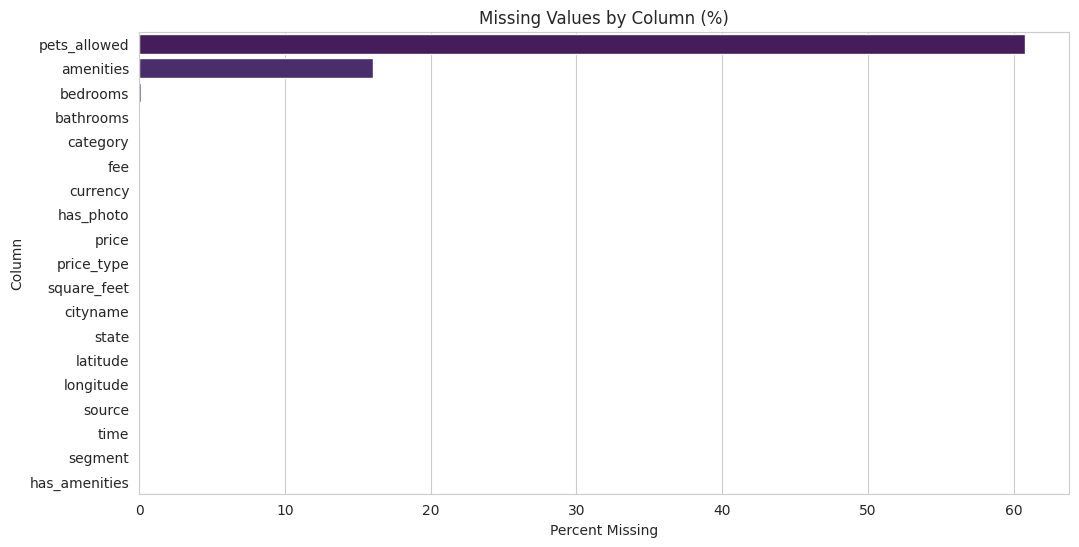

In [9]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=missing,
    x='Missing_%',
    y='Column',
    palette='viridis'
)

plt.title('Missing Values by Column (%)')
plt.xlabel('Percent Missing')
plt.show()

What factors most strongly influence rental prices?

In [10]:
num_cols = [
    'price',
    'bedrooms',
    'bathrooms',
    'square_feet',
    'latitude',
    'longitude',
    'has_photo'
]

corr = df_clean[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix') #looking for the strongest correlations with price
plt.show()

ValueError: could not convert string to float: 'Yes'

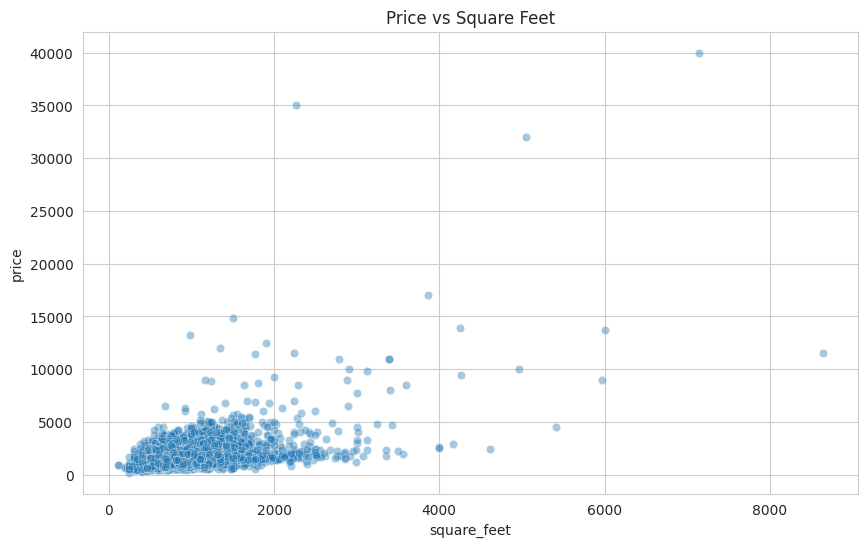

In [11]:
sns.scatterplot(
    data=df_clean.sample(10000),
    x='square_feet',
    y='price',
    alpha=.4
)

plt.title('Price vs Square Feet')
plt.show()

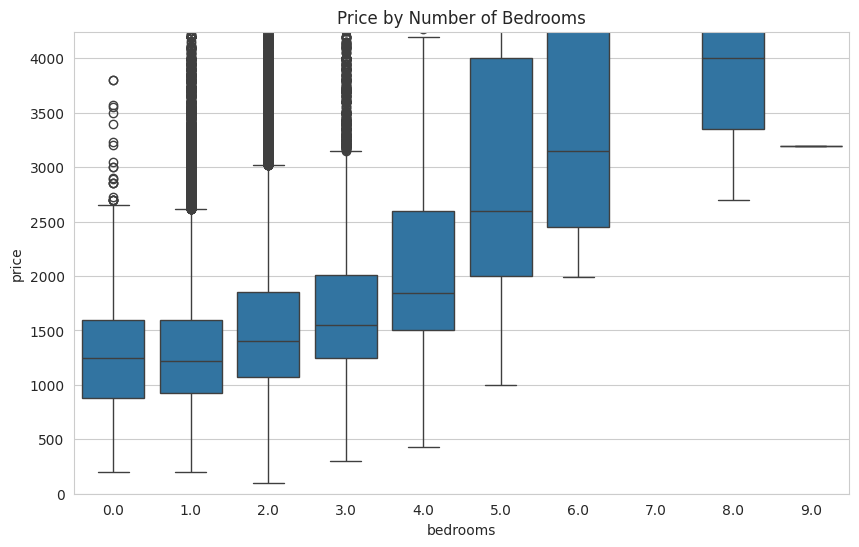

In [12]:
sns.boxplot(
    data=df_clean,
    x='bedrooms',
    y='price'
)

plt.ylim(0, df_clean['price'].quantile(.99))
plt.title('Price by Number of Bedrooms')
plt.show()

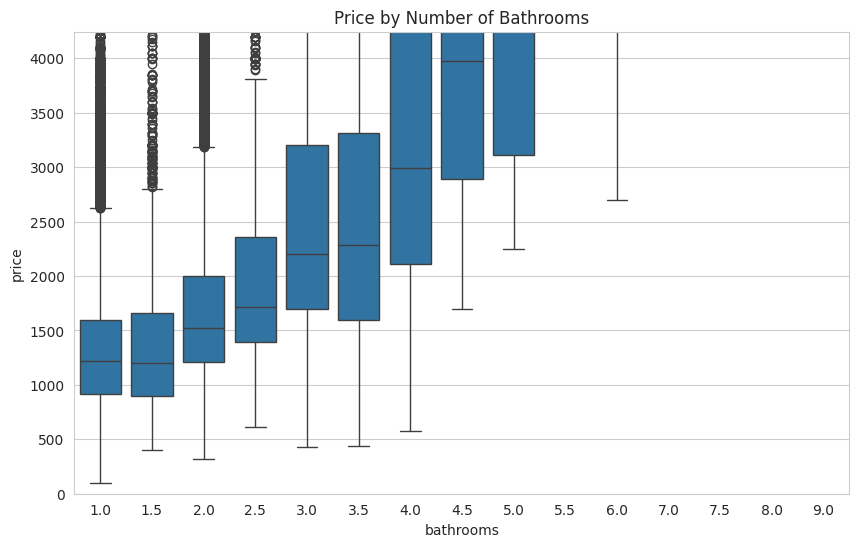

In [13]:
sns.boxplot(
    data=df_clean,
    x='bathrooms',
    y='price'
)

plt.ylim(0, df_clean['price'].quantile(.99))
plt.title('Price by Number of Bathrooms')
plt.show()

How do bedrooms, bathrooms, square footage, location, and amenities affect pricing?

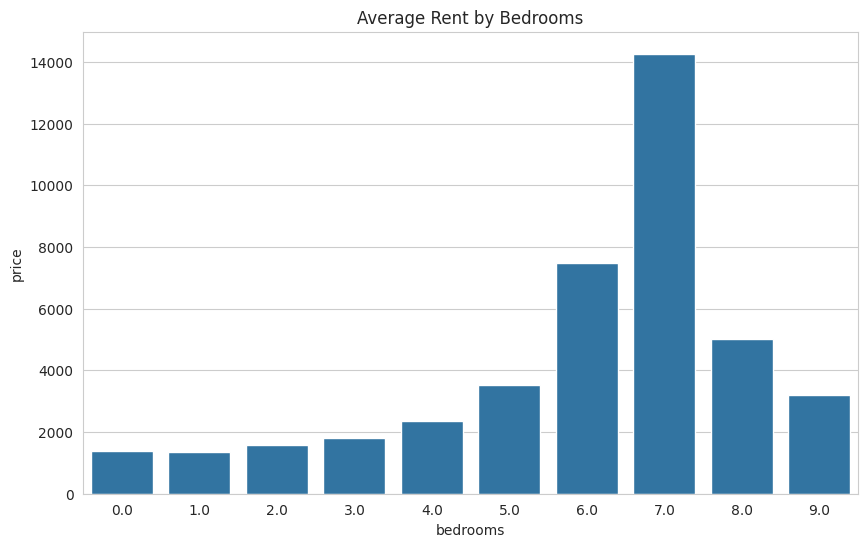

In [14]:
bedroom_price = (
    df_clean.groupby('bedrooms')['price']
    .mean()
    .reset_index()
)

sns.barplot(
    data=bedroom_price,
    x='bedrooms',
    y='price'
)

plt.title('Average Rent by Bedrooms')
plt.show()

Why is the peak price at 7 bedrooms? Shouldn't the price be increasing each bedroom instead of dropping after 7?

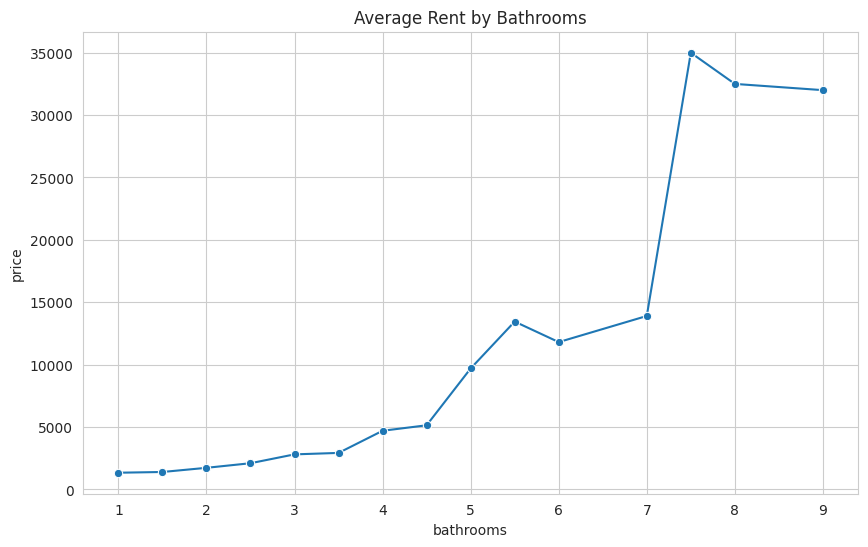

In [15]:
bathroom_price = (
    df_clean.groupby('bathrooms')['price']
    .mean()
    .reset_index()
)

sns.lineplot(
    data=bathroom_price,
    x='bathrooms',
    y='price',
    marker='o'
)

plt.title('Average Rent by Bathrooms')
plt.show()

In [16]:
df_clean['has_amenities'] = np.where(
    df_clean['amenities'].notnull(),
    1,
    0
)

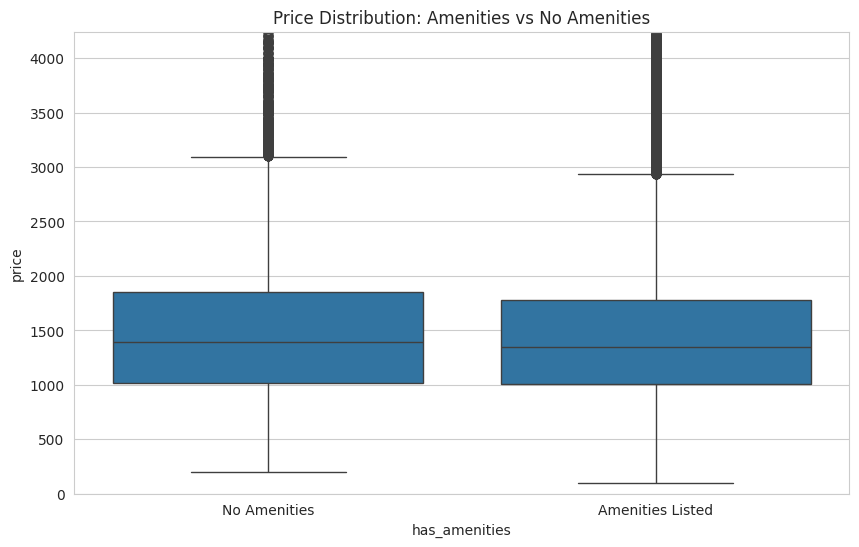

In [17]:
sns.boxplot(
    data=df_clean,
    x='has_amenities',
    y='price'
)

plt.ylim(0, df_clean['price'].quantile(.99))
plt.title('Price Distribution: Amenities vs No Amenities')
plt.xticks([0,1],['No Amenities','Amenities Listed'])
plt.show()

This doesn't make much sense to have the price be lower with a column that should add conveinance.

How does rental price vary geographically?

/tmp/ipykernel_1780/1883775313.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


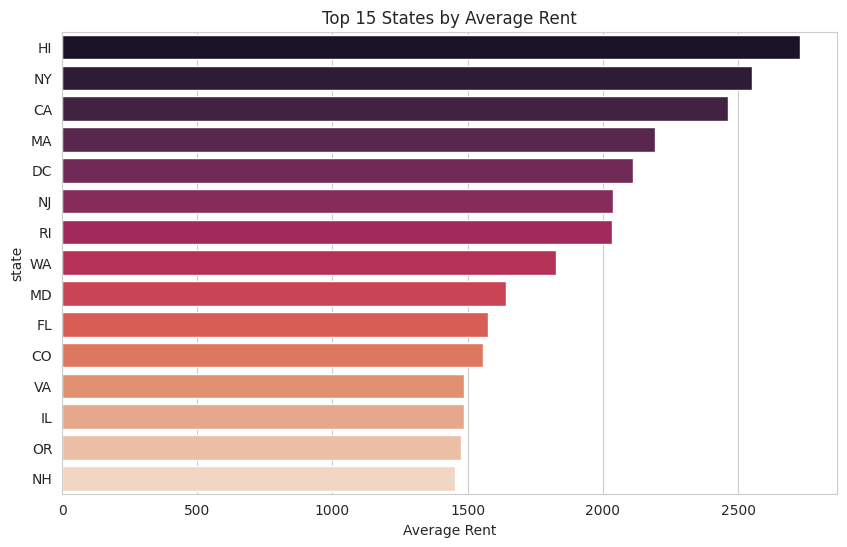

In [18]:
state_price = (
    df_clean.groupby('state')['price']
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=state_price.values,
    y=state_price.index,
    palette='rocket'
)

plt.title('Top 15 States by Average Rent')
plt.xlabel('Average Rent')
plt.show()

/tmp/ipykernel_1780/915944426.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


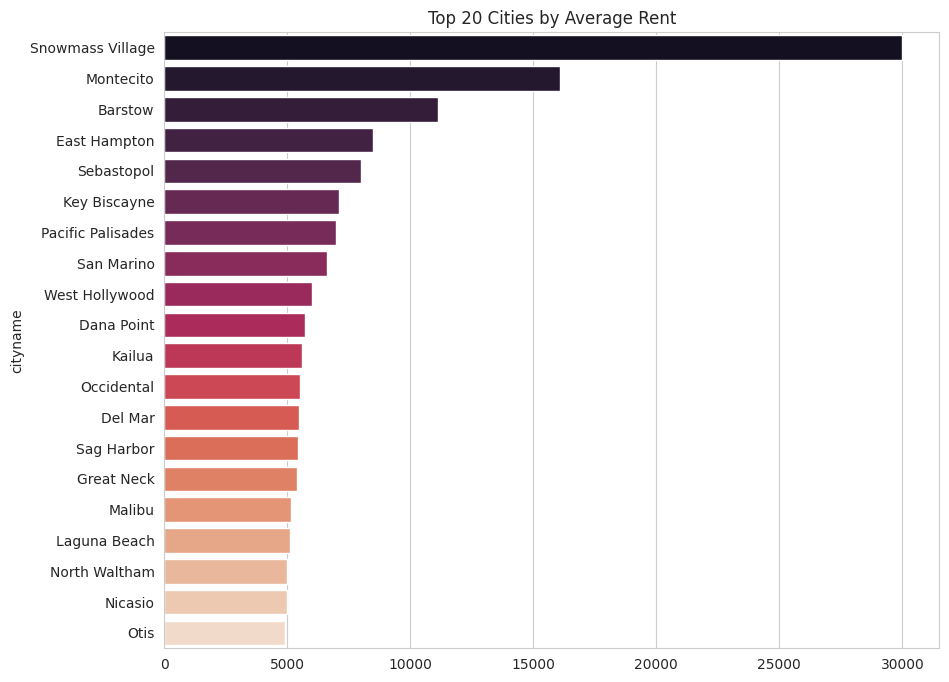

In [19]:
city_price = (
    df_clean.groupby('cityname')['price']
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(10,8))

sns.barplot(
    x=city_price.values,
    y=city_price.index,
    palette='rocket'
)

plt.title('Top 20 Cities by Average Rent')
plt.show()

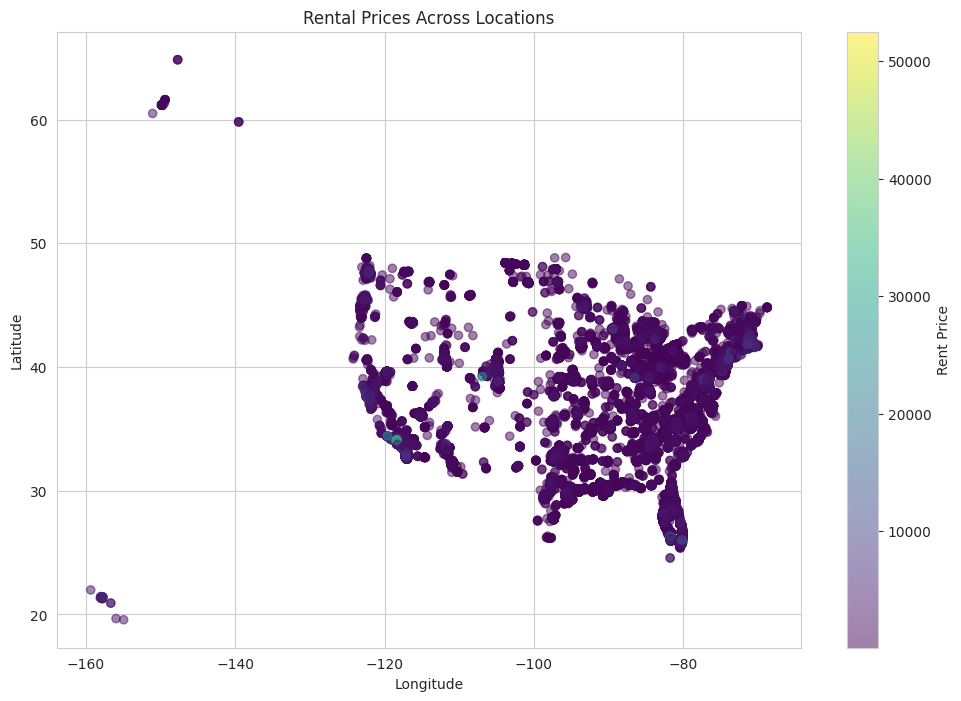

In [20]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    df_clean['longitude'],
    df_clean['latitude'],
    c=df_clean['price'],
    cmap='viridis',
    alpha=.5
)

plt.colorbar(scatter,label='Rent Price')

plt.title('Rental Prices Across Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

Are there regional patterns of high-cost vs low-cost markets?

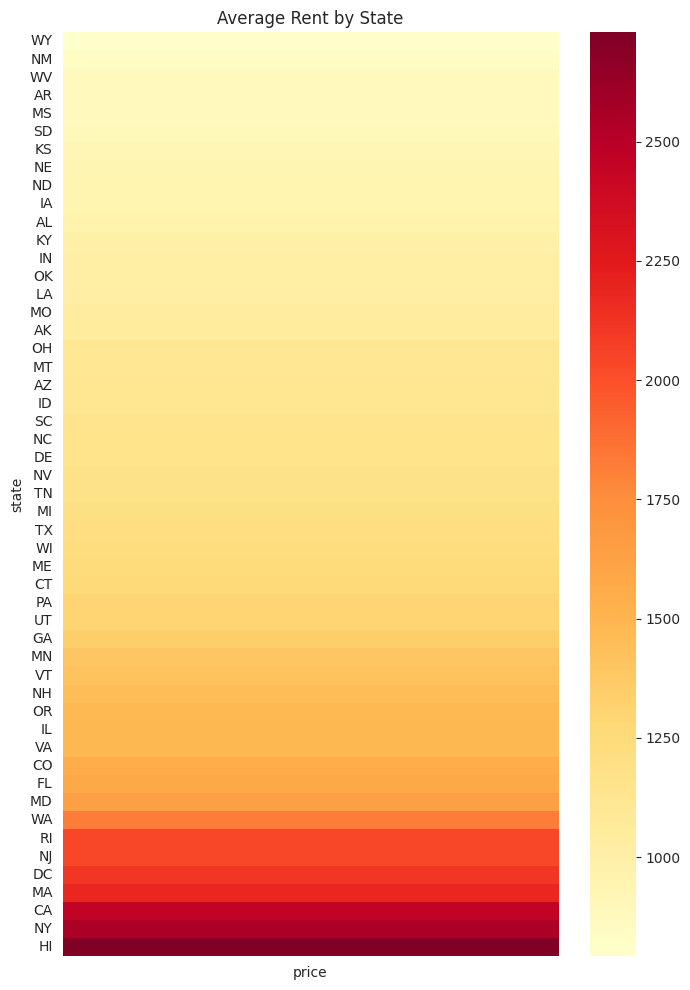

In [21]:
state_summary = (
    df_clean.groupby('state')['price']
    .mean()
    .sort_values()
)

plt.figure(figsize=(8,12))

sns.heatmap(
    state_summary.to_frame(),
    cmap='YlOrRd'
)

plt.title('Average Rent by State')
plt.show()

Do photos, amenities, or pet policies affect price?

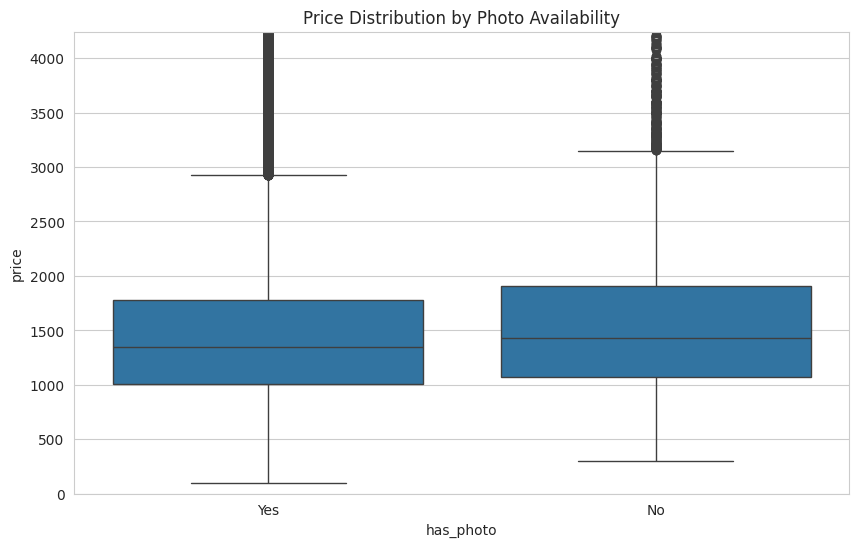

In [22]:
sns.boxplot(
    data=df_clean,
    x='has_photo',
    y='price'
)

plt.ylim(0, df_clean['price'].quantile(.99))
plt.title('Price Distribution by Photo Availability')
plt.show()

Another interesting thing to look at, why is it lower in price?

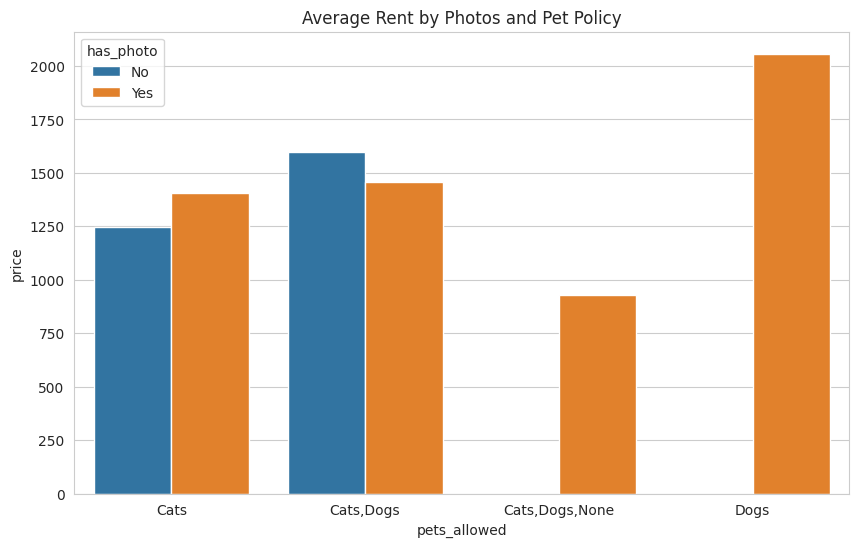

In [23]:
feature_price = (
    df_clean.groupby(
        ['pets_allowed','has_photo']
    )['price']
    .mean()
    .reset_index()
)

sns.barplot(
    data=feature_price,
    x='pets_allowed',
    y='price',
    hue='has_photo'
)

plt.title('Average Rent by Photos and Pet Policy')
plt.show()

In this dataset, listings with photos have a slightly lower average rent.

In [24]:
df_clean.groupby(
    ['pets_allowed','has_photo']
).size()

pets_allowed    has_photo
Cats            No             137
                Yes           1703
Cats,Dogs       No            2480
                Yes          34559
Cats,Dogs,None  Yes              1
Dogs            Yes            126
dtype: int64

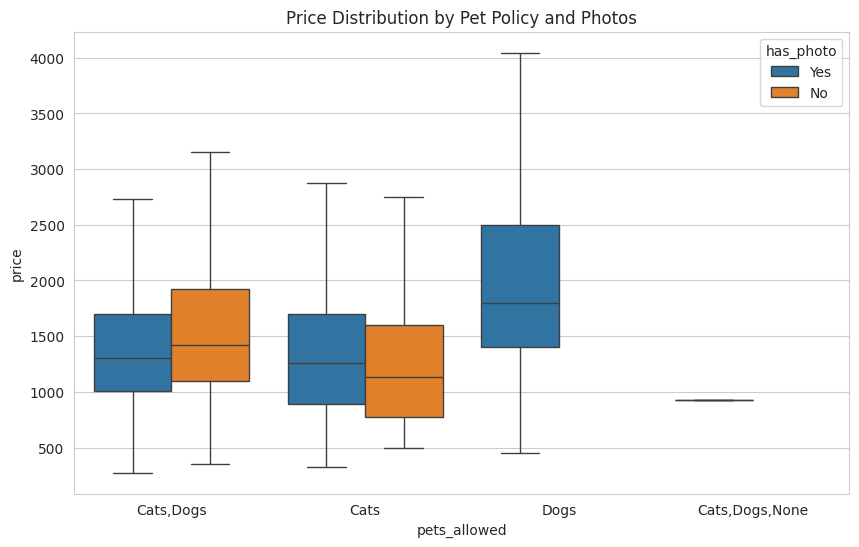

In [25]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_clean,
    x='pets_allowed',
    y='price',
    hue='has_photo',
    showfliers=False
)

plt.title('Price Distribution by Pet Policy and Photos')
plt.show()

What does the distribution of rental segments look like?

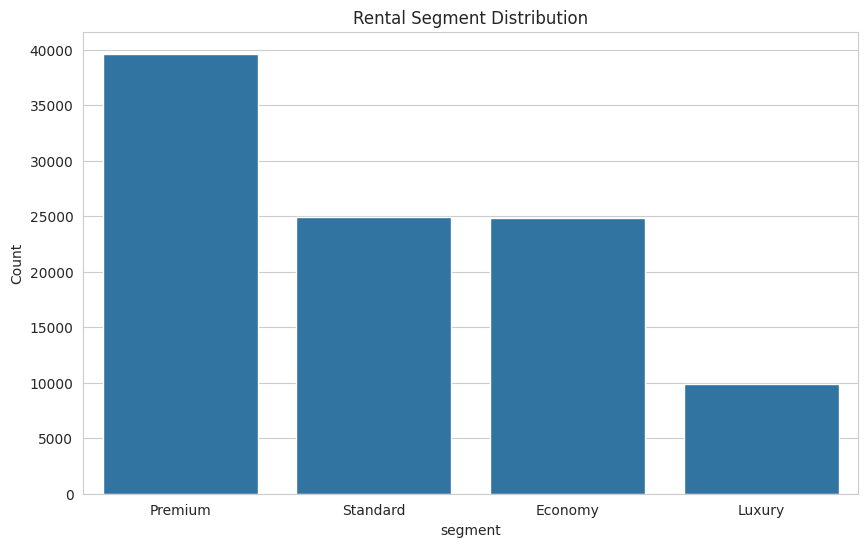

In [26]:
segment_counts = (
    df_clean['segment']
    .value_counts()
)

sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values
)

plt.title('Rental Segment Distribution')
plt.ylabel('Count')
plt.show()

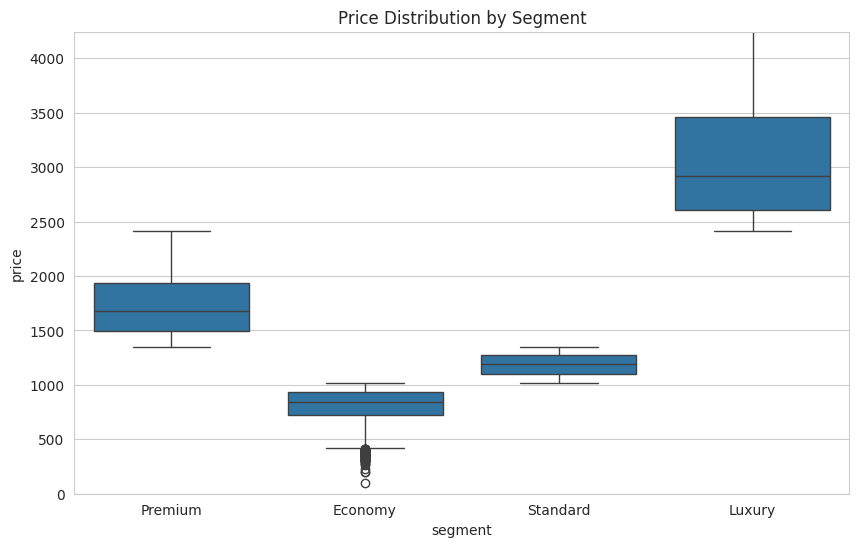

In [27]:
sns.boxplot(
    data=df_clean,
    x='segment',
    y='price'
)

plt.ylim(0, df_clean['price'].quantile(.99))
plt.title('Price Distribution by Segment')
plt.show()

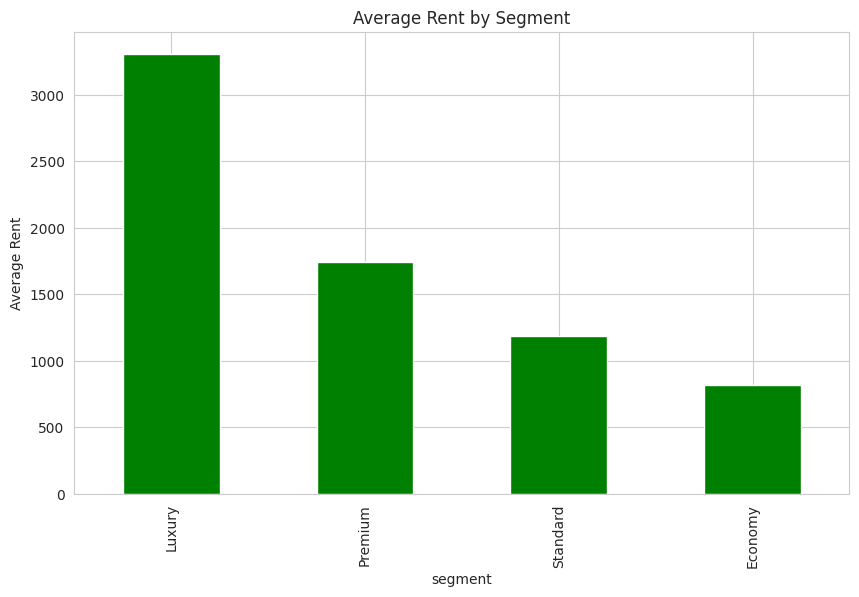

In [28]:
segment_price = (
    df_clean.groupby('segment')['price']
    .mean()
    .sort_values(ascending=False)
)

segment_price.plot(
    kind='bar',
    color='green'
)

plt.title('Average Rent by Segment')
plt.ylabel('Average Rent')
plt.show()

In [29]:
df_clean['segment'].value_counts()

,count
segment,
Premium,39656
Standard,24982
Economy,24886
Luxury,9858


In [30]:
df_clean[df_clean['segment'] == 'luxury'][['price']].describe()

,price
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


In [31]:
df_clean[df_clean['segment'] == 'luxury'].head()

,category,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,cityname,state,latitude,longitude,source,time,segment,has_amenities


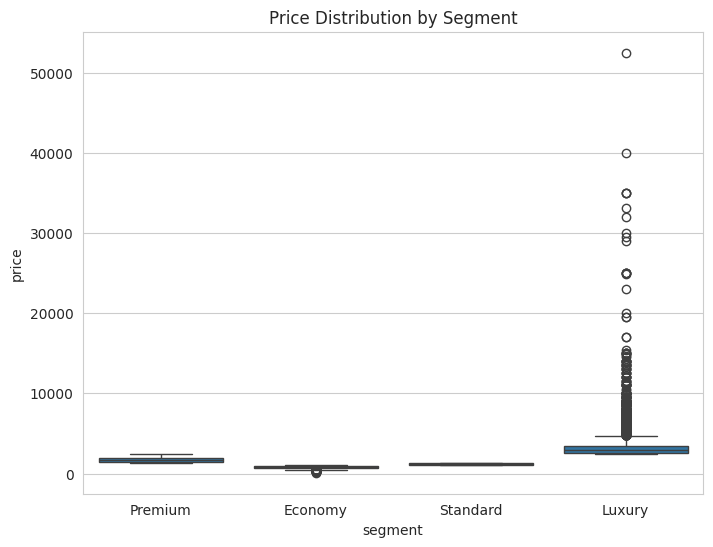

In [34]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_clean,
    x='segment',
    y='price'
)

plt.title('Price Distribution by Segment')
plt.show()

In [35]:
df_clean.groupby('segment')['price'].agg(
    ['count','min','median','mean','max']
)

,count,min,median,mean,max
segment,,,,,
Economy,24886,100.0,845.0,818.974965,1014.0
Luxury,9858,2411.0,2919.5,3305.632684,52500.0
Premium,39656,1351.0,1679.0,1738.699945,2410.0
Standard,24982,1015.0,1195.0,1187.782003,1350.0


In [36]:
df_clean['segment'].value_counts(normalize=True) * 100

,proportion
segment,
Premium,39.902598
Standard,25.137349
Economy,25.040752
Luxury,9.919301


In [37]:
df_clean['segment'] = pd.qcut(
    df_clean['price'],
    q=[0, 0.25, 0.50, 0.90, 1],
    labels=['Economy', 'Standard', 'Premium', 'Luxury']
)

In [38]:
df_clean['segment'].value_counts()

,count
segment,
Premium,39576
Standard,25020
Economy,24848
Luxury,9938


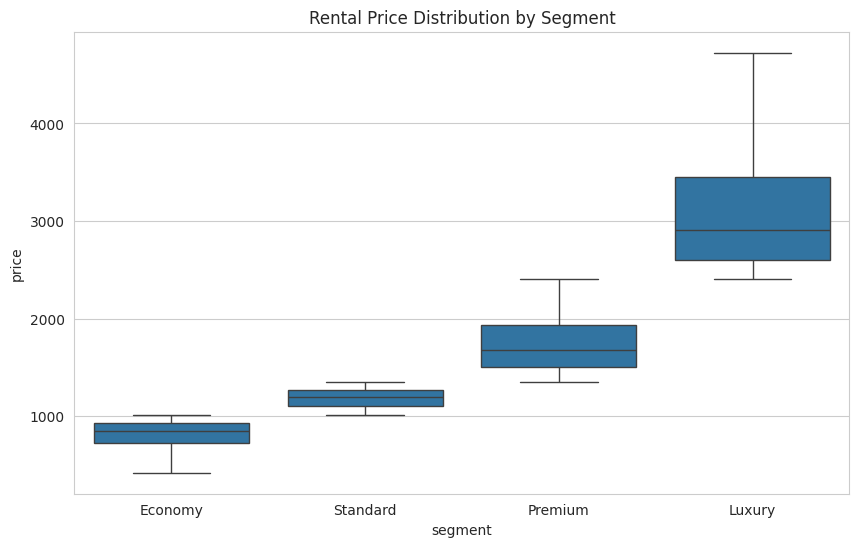

In [39]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_clean,
    x='segment',
    y='price',
    showfliers=False
)

plt.title('Rental Price Distribution by Segment')
plt.show()

Random Forest Model to evaluate "What factors most strongly influence rental prices?"

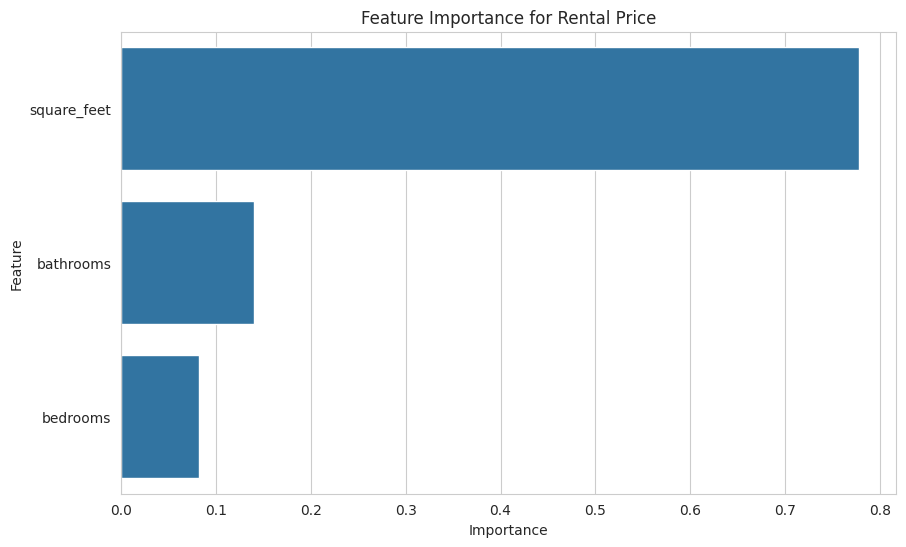

In [45]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

features = [
    'bedrooms',
    'bathrooms',
    'square_feet'
]

data = df_clean[features + ['price']].dropna()

X = data[features]
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=.2,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values(
    'Importance',
    ascending=False
)

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title('Feature Importance for Rental Price')
plt.show()

In [43]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Predictions
y_pred = rf.predict(X_test)

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

summary = pd.DataFrame({
    'Metric': ['R²', 'MAE', 'RMSE'],
    'Value': [r2, mae, rmse]
})

print(summary)

  Metric       Value
0     R²    0.115608
1    MAE  492.736896
2   RMSE  774.322345


Doing more cleaning because my data was still giving me trouble.

In [124]:
df_clean['price'].describe(percentiles=[.01,.05,.95,.99])

,price
count,99819.000000
mean,1527.224015
std,903.638141
min,100.000000
1%,545.000000
5%,699.000000
50%,1350.000000
95%,2924.000000
99%,4250.000000
max,52500.000000


In [125]:
df_clean.nlargest(20, 'price')[
    ['price','bedrooms','bathrooms','square_feet','cityname','state']
]

,price,bedrooms,bathrooms,square_feet,cityname,state
394,52500.0,0.0,1.0,1418.0,Barstow,CA
99770,40000.0,6.0,8.0,7145.0,Los Angeles,CA
98087,35000.0,4.0,4.0,2269.0,West Hollywood,CA
99772,35000.0,6.0,7.5,6366.0,West Hollywood,CA
99815,35000.0,7.0,5.0,5586.0,West Hollywood,CA
87969,33165.0,3.0,2.5,2211.0,Pacific Palisades,CA
99775,32000.0,6.0,9.0,5055.0,Los Angeles,CA
99570,30000.0,5.0,5.5,5872.0,Snowmass Village,CO
87996,29500.0,3.0,3.0,4291.0,Venice,CA
99774,29500.0,6.0,NaN,11000.0,Los Angeles,CA


In [126]:
df_clean.nsmallest(20, 'price')[
    ['price','bedrooms','bathrooms','square_feet','cityname','state']
]

,price,bedrooms,bathrooms,square_feet,cityname,state
84208,100.0,2.0,1.0,800.0,Hartford,CT
514,200.0,0.0,1.0,800.0,Russellville,AR
32942,200.0,1.0,1.0,250.0,Mount Airy,MD
22078,224.0,1.0,1.0,587.0,Decatur,IN
29827,264.0,1.0,1.0,750.0,Burlington,NC
98,275.0,NaN,NaN,300.0,Lakeland,FL
21700,285.0,1.0,1.0,400.0,Talladega,AL
21392,288.0,1.0,1.0,766.0,Michigan City,IN
25274,299.0,1.0,1.0,736.0,Columbus,OH
89,300.0,NaN,1.0,245.0,Delphi,IN


In [127]:
df_clean['square_feet'].describe()

,square_feet
count,99820.000000
mean,956.411691
std,417.253229
min,101.000000
25%,729.000000
50%,900.000000
75%,1115.000000
max,50000.000000


In [128]:
df_clean.nlargest(20, 'square_feet')[
    ['price','square_feet','bedrooms','cityname']
]

,price,square_feet,bedrooms,cityname
38889,2640.0,50000.0,1.0,None
38741,4790.0,40000.0,1.0,New York
611,565.0,12000.0,0.0,Euclid
99801,11000.0,11318.0,6.0,Potomac
99774,29500.0,11000.0,6.0,Los Angeles
617,4000.0,9998.0,0.0,Steubenville
244,1475.0,9175.0,0.0,Los Angeles
99769,25000.0,8716.0,6.0,Montecito
99730,11500.0,8643.0,5.0,Bedford
99771,29000.0,7213.0,6.0,Beverly Hills


In [129]:
df_clean.nsmallest(20, 'square_feet')[
    ['price','square_feet','bedrooms','cityname']
]

,price,square_feet,bedrooms,cityname
685,790.0,101.0,0.0,Washington
21136,425.0,106.0,1.0,Evansville
652,1390.0,107.0,0.0,Arlington
24,1100.0,116.0,NaN,Los Angeles
179,925.0,116.0,0.0,Seattle
647,880.0,125.0,0.0,Arlington
723,2475.0,130.0,0.0,Manhattan
213,1800.0,132.0,0.0,Venice
671,840.0,136.0,0.0,Washington
148,1495.0,138.0,0.0,San Francisco


In [130]:
df_clean[
    (df_clean['square_feet'] > 15000) |
    (
        (df_clean['bedrooms'] == 0) &
        (df_clean['square_feet'] > 5000)
    )
][['price','square_feet','bedrooms','bathrooms','cityname']]

,price,square_feet,bedrooms,bathrooms,cityname
244,1475.0,9175.0,0.0,1.0,Los Angeles
611,565.0,12000.0,0.0,1.0,Euclid
617,4000.0,9998.0,0.0,1.0,Steubenville
38741,4790.0,40000.0,1.0,NaN,New York
38889,2640.0,50000.0,1.0,NaN,None


In [131]:
df_clean = df_clean[
    ~(
        (df_clean['square_feet'] > 15000)
        |
        (
            (df_clean['bedrooms'] == 0)
            &
            (df_clean['square_feet'] > 5000)
        )
    )
]

In [132]:
df_clean['price_per_sqft'] = (
    df_clean['price'] /
    df_clean['square_feet']
)

In [133]:
df_clean.nsmallest(
    20,
    'price_per_sqft'
)[
    ['price','square_feet','bedrooms','cityname','price_per_sqft']
]

,price,square_feet,bedrooms,cityname,price_per_sqft
84208,100.0,800.0,2.0,Hartford,0.125000
98887,430.0,2214.0,4.0,Pendleton,0.194219
608,350.0,1764.0,0.0,Cleveland,0.198413
514,200.0,800.0,0.0,Russellville,0.250000
92172,300.0,1150.0,3.0,Battle Creek,0.260870
93826,500.0,1900.0,3.0,Richlands,0.263158
25368,382.0,1442.0,1.0,Clemson,0.264910
97378,750.0,2812.0,3.0,Colebrook,0.266714
65339,595.0,2216.0,2.0,Dayton,0.268502
93264,700.0,2600.0,3.0,Detroit,0.269231


In [134]:
df_clean.nlargest(
    20,
    'price_per_sqft'
)[
    ['price','square_feet','bedrooms','cityname','price_per_sqft']
]

,price,square_feet,bedrooms,cityname,price_per_sqft
394,52500.0,1418.0,0.0,Barstow,37.023977
723,2475.0,130.0,0.0,Manhattan,19.038462
98087,35000.0,2269.0,4.0,West Hollywood,15.425297
43785,12995.0,865.0,2.0,Los Angeles,15.023121
87969,33165.0,2211.0,3.0,Pacific Palisades,15.000000
44303,8700.0,607.0,2.0,West Hollywood,14.332784
213,1800.0,132.0,0.0,Venice,13.636364
99288,13278.0,988.0,4.0,New York,13.439271
652,1390.0,107.0,0.0,Arlington,12.990654
83789,6100.0,500.0,2.0,New York,12.200000


In [135]:
# Missing locations
df_clean[df_clean['cityname'].isna()]

# Weird prices
df_clean[df_clean['price'] < 100]

# Weird sqft
df_clean[df_clean['square_feet'] < 100]

# Weird bedrooms
df_clean[df_clean['bedrooms'] > 10]

# Weird bathrooms
df_clean[df_clean['bathrooms'] > 10]

,category,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,cityname,state,latitude,longitude,source,time,segment,has_amenities,price_per_sqft


In [136]:
# Missing city/state
print(df_clean['cityname'].isna().sum())
print(df_clean['state'].isna().sum())

# Negative or zero values
print(df_clean[df_clean['price'] <= 0].shape)
print(df_clean[df_clean['square_feet'] <= 0].shape)

# Extremely large values
print(df_clean[df_clean['price'] > 10000].shape)
print(df_clean[df_clean['square_feet'] > 10000].shape)

304
304
(0, 20)
(0, 20)
(72, 20)
(2, 20)


In [137]:
df_clean[df_clean['square_feet'] > 10000][
    ['price','square_feet','bedrooms','bathrooms','cityname','state']
]

,price,square_feet,bedrooms,bathrooms,cityname,state
99774,29500.0,11000.0,6.0,NaN,Los Angeles,CA
99801,11000.0,11318.0,6.0,8.5,Potomac,MD


In [138]:
df_clean = df_clean[df_clean['square_feet'] <= 10000]

In [139]:
df_clean = df_clean.dropna(
    subset=['cityname','state']
)

In [140]:
df_clean[df_clean['bedrooms'] > 8][
    ['price','bedrooms','bathrooms','square_feet']
]

,price,bedrooms,bathrooms,square_feet
99822,3195.0,9.0,5.0,4000.0


In [141]:
df_clean[df_clean['bathrooms'] > 8][
    ['price','bedrooms','bathrooms','square_feet']
]

,price,bedrooms,bathrooms,square_feet
99775,32000.0,6.0,9.0,5055.0


In [142]:
df_clean.duplicated().sum()

np.int64(129)

In [143]:
df_clean = df_clean.drop_duplicates()

In [144]:
# Remove missing locations
df_clean = df_clean.dropna(
    subset=['cityname','state']
)

# Remove extreme sqft outliers
df_clean = df_clean[
    df_clean['square_feet'] <= 10000
]

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

In [145]:
df_clean.shape

(99383, 20)

In [146]:
df_clean[['price','square_feet','bedrooms','bathrooms']].describe()

,price,square_feet,bedrooms,bathrooms
count,99382.000000,99383.000000,99259.000000,99326.000000
mean,1525.336510,955.070203,1.727944,1.445311
std,898.168103,360.535433,0.748445,0.546549
min,100.000000,101.000000,0.000000,1.000000
25%,1013.000000,729.000000,1.000000,1.000000
50%,1350.000000,900.000000,2.000000,1.000000
75%,1795.000000,1115.000000,2.000000,2.000000
max,52500.000000,8716.000000,9.000000,9.000000


In [147]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99383 entries, 3 to 99822
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   category        99383 non-null  object        
 1   amenities       99383 non-null  object        
 2   bathrooms       99326 non-null  float64       
 3   bedrooms        99259 non-null  float64       
 4   currency        99383 non-null  object        
 5   fee             99383 non-null  object        
 6   has_photo       99383 non-null  Int64         
 7   pets_allowed    39007 non-null  object        
 8   price           99382 non-null  float64       
 9   price_type      99383 non-null  object        
 10  square_feet     99383 non-null  float64       
 11  cityname        99383 non-null  object        
 12  state           99383 non-null  object        
 13  latitude        99383 non-null  float64       
 14  longitude       99383 non-null  float64       
 15  source 

In [148]:
df_clean = df_clean.dropna(subset=['price'])

In [149]:
df_clean = df_clean.drop(columns=['price_per_sqft'])

In [150]:
df_clean['segment'] = df_clean['segment'].astype(str)

In [151]:
df_clean['has_photo'] = df_clean['has_photo'].map({1: 'Yes', 0: 'No'})

In [153]:
df_clean.columns = df_clean.columns.str.lower().str.replace(' ', '_')

In [154]:
df_clean.head()

,category,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,cityname,state,latitude,longitude,source,time,segment,has_amenities
3,housing/rent/apartment,Cable or Satellite TV,1.0,NaN,USD,No,Yes,"Cats,Dogs",1400.0,Monthly,320.0,Forestville,CA,38.4909,-122.9041,RentDigs.com,2019-02-22 06:34:29,Premium,Yes
4,housing/rent/apartment,AC Cable or Satellite Internet Access,1.0,NaN,USD,No,Yes,"Cats,Dogs",550.0,Monthly,600.0,Tacoma,WA,47.1473,-122.4557,RentDigs.com,2019-04-14 09:13:34,Economy,Yes
5,housing/rent/apartment,Refrigerator,1.0,NaN,USD,No,Yes,None,970.0,Monthly,300.0,Vallejo,CA,38.1048,-122.2468,RentDigs.com,2018-12-08 11:01:36,Economy,Yes
6,housing/rent/apartment,Cable or Satellite TV,1.0,NaN,USD,No,Yes,"Cats,Dogs",1075.0,Monthly,450.0,Citrus Heights,CA,38.6952,-121.2653,RentDigs.com,2019-02-22 07:11:59,Standard,Yes
7,housing/rent/apartment,AC Basketball Cable or Satellite Clubhouse Gat...,1.0,NaN,USD,No,Yes,None,1195.0,Monthly,895.0,Reno,NV,39.5475,-119.7975,RentDigs.com,2019-07-07 09:01:56,Standard,Yes


In [160]:
import numpy as np

df_clean['amenities'] = df_clean['amenities'].astype(str).str.strip()

df_clean.loc[
    df_clean['amenities'].str.lower().isin(['nan', 'none', 'null', '']),
    'amenities'
] = np.nan

In [161]:
# 1. Drop missing price
df_clean = df_clean.dropna(subset=['price'])

# 2. Convert types for Power BI
df_clean['segment'] = df_clean['segment'].astype(str)


df_clean['has_amenities'] = df_clean['amenities'].notna().replace({True: 'Yes', False: 'No'})

# 3. Optional: remove derived column if not needed
# df_clean = df_clean.drop(columns=['price_per_sqft'])

# 4. Reset index
df_clean = df_clean.reset_index(drop=True)

In [162]:
df_clean[df_clean['has_amenities'] == 'No'].head()

,category,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,cityname,state,latitude,longitude,source,time,segment,has_amenities
22,housing/rent/apartment,NaN,1.0,NaN,USD,No,Yes,None,1400.0,Monthly,410.0,Los Angeles,CA,34.1176,-118.3327,RentDigs.com,2019-09-17 22:39:27,Premium,No
27,housing/rent/apartment,NaN,1.0,NaN,USD,No,Yes,None,1350.0,Monthly,500.0,Los Angeles,CA,34.0899,-118.2932,RentDigs.com,2019-09-17 20:24:53,Standard,No
28,housing/rent/apartment,NaN,1.0,NaN,USD,No,Yes,None,1350.0,Monthly,500.0,Los Angeles,CA,34.0899,-118.2932,RentDigs.com,2019-09-17 20:24:44,Standard,No
29,housing/rent/apartment,NaN,1.0,NaN,USD,No,Yes,None,1350.0,Monthly,500.0,Los Angeles,CA,34.0899,-118.2932,RentDigs.com,2019-09-17 20:24:15,Standard,No
31,housing/rent/apartment,NaN,1.0,NaN,USD,No,Yes,"Cats,Dogs",1195.0,Monthly,400.0,Los Angeles,CA,34.0480,-118.2908,RentDigs.com,2018-12-07 17:34:31,Standard,No


In [163]:
from pandas_gbq import to_gbq

to_gbq(
    df_clean,
    destination_table='ndata.apts_clean',
    project_id='my-capstone-498914',
    if_exists='replace'
)

100%|██████████| 1/1 [00:00<00:00, 18001.30it/s]


In [164]:
df_clean.to_csv('rental_housing_cleaned.csv', index=False)

In [81]:
df_clean['segment'].unique()

['Premium', 'Standard', 'Luxury']
Categories (3, object): ['Standard' < 'Premium' < 'Luxury']